In [1]:
import pandas as pd
import numpy as np

In [5]:
heart = pd.read_csv('clevelanda.csv')

In [6]:
heart.head()

,age,gender,cp,trestbps,chol,fps,restecg,thalach,exang,oldpeak,slope,ca,thal,class
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0


In [7]:
heart.shape

(303, 14)

In [8]:
heart['age'].mean()

np.float64(54.43894389438944)

In [9]:
heart['age'].median()

np.float64(56.0)

In [10]:
heart['age'].mode()

0    58
Name: age, dtype: int64

In [12]:
!pip install matplotlib

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 2.5 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/9.3 MB 2.4 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.3 MB 3.1 MB/s eta 0:00:03
   ----------- ---------------------------- 2.6/9.3 MB 3.2 MB/s eta 0:00:03
   -------------- ------------------------- 3.4/9.3 MB 3.3 MB/s eta 0:00:02
   ---------------- ----------------------- 3.9/9.3 MB 3.1 MB/s eta 0:00:02
   -------------------- ------------------- 4.7/9.3 MB 3.2 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.3 MB 3.2 MB/s eta 0:00:02
   -------------------------- ------------- 6.3/9.3 MB 3.3 MB/s eta 0:00:01
   ----------------------------- ---------- 6.8/9.3 MB 3.3 MB/s eta 0:00:01
   -------------------------------- ------- 7.6/9.3 MB 3.3 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.3 MB 3.3 MB/s eta 0:00:01
   ----------------

<Axes: >

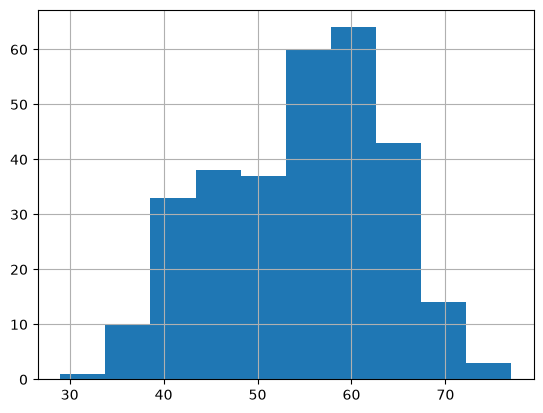

In [13]:
heart['age'].hist()

In [14]:
heart['age'].skew()

np.float64(-0.20906046882012877)

In [15]:
heart['age'].describe()

count    303.000000
mean      54.438944
std        9.038662
min       29.000000
25%       48.000000
50%       56.000000
75%       61.000000
max       77.000000
Name: age, dtype: float64

In [16]:
#Kurtosis is a measure of the "tailedness" of the probability distribution of a real-valued random variable. It describes the shape of the distribution, specifically how heavy or light the tails are compared to a normal distribution. A high kurtosis indicates that the distribution has heavy tails and more outliers, while a low kurtosis indicates that the distribution has light tails and fewer outliers.
heart['age'].kurtosis()

np.float64(-0.5233827452226572)

In [17]:
heart['thalach'].describe()

count    303.000000
mean     149.607261
std       22.875003
min       71.000000
25%      133.500000
50%      153.000000
75%      166.000000
max      202.000000
Name: thalach, dtype: float64

In [18]:
heart['thalach'].kurtosis()

np.float64(-0.053540958946916906)

In [19]:
heart = heart.replace('?', np.nan)

In [32]:
heart['ca'] = pd.to_numeric(heart['ca'])
heart['thal'] = pd.to_numeric(heart['thal'])

In [33]:
heart = heart.dropna(axis=0)

In [34]:
d = heart.corr()

In [35]:
import matplotlib.pyplot as plt

In [36]:
!pip install seaborn

In [37]:
import seaborn as sns

<Axes: >

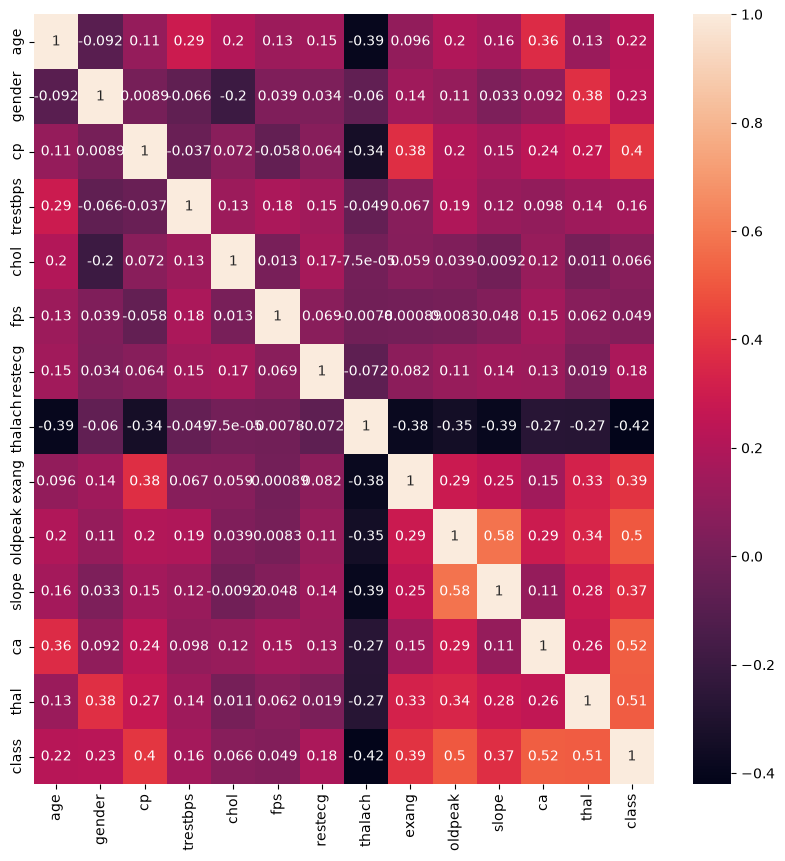

In [38]:
plt.figure(figsize=(10, 10))
sns.heatmap(d, annot=True)

In [28]:
!pip install plotly-express

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.9 MB 2.4 MB/s eta 0:00:04
   ---- ----------------------------------- 1.0/9.9 MB 2.3 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.9 MB 2.7 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.9 MB 2.8 MB/s eta 0:00:03
   ------------ --------------------------- 3.1/9.9 MB 3.0 MB/s eta 0:00:03
   --------------- ------------------------ 3.9/9.9 MB 3.1 MB/s eta 0:00:02
   ------------------- -------------------- 4.7/9.9 MB 3.1 MB/s eta 0:00:02
   ---------------------- ----------------- 5.5/9.9 MB 3.2 MB/s eta 0:00:02
   ------------------------- -------------- 6.3/9.9 MB 3.2 MB/s eta 0:00:02
   --------------------------- ------------ 6.8/9.9 MB 3.2 MB/s eta 0:00:01
   ------------------------------ --------- 7.6/9.9 MB 3.2 MB/s eta 0:00:01
   --------------------------------- ------ 8.4/9.9 MB 3.3 MB/s eta 0:00:01
   ----------------

In [29]:
import plotly.express as px

In [39]:
fig = px.scatter(heart, x='age', y='trestbps')
fig.show()

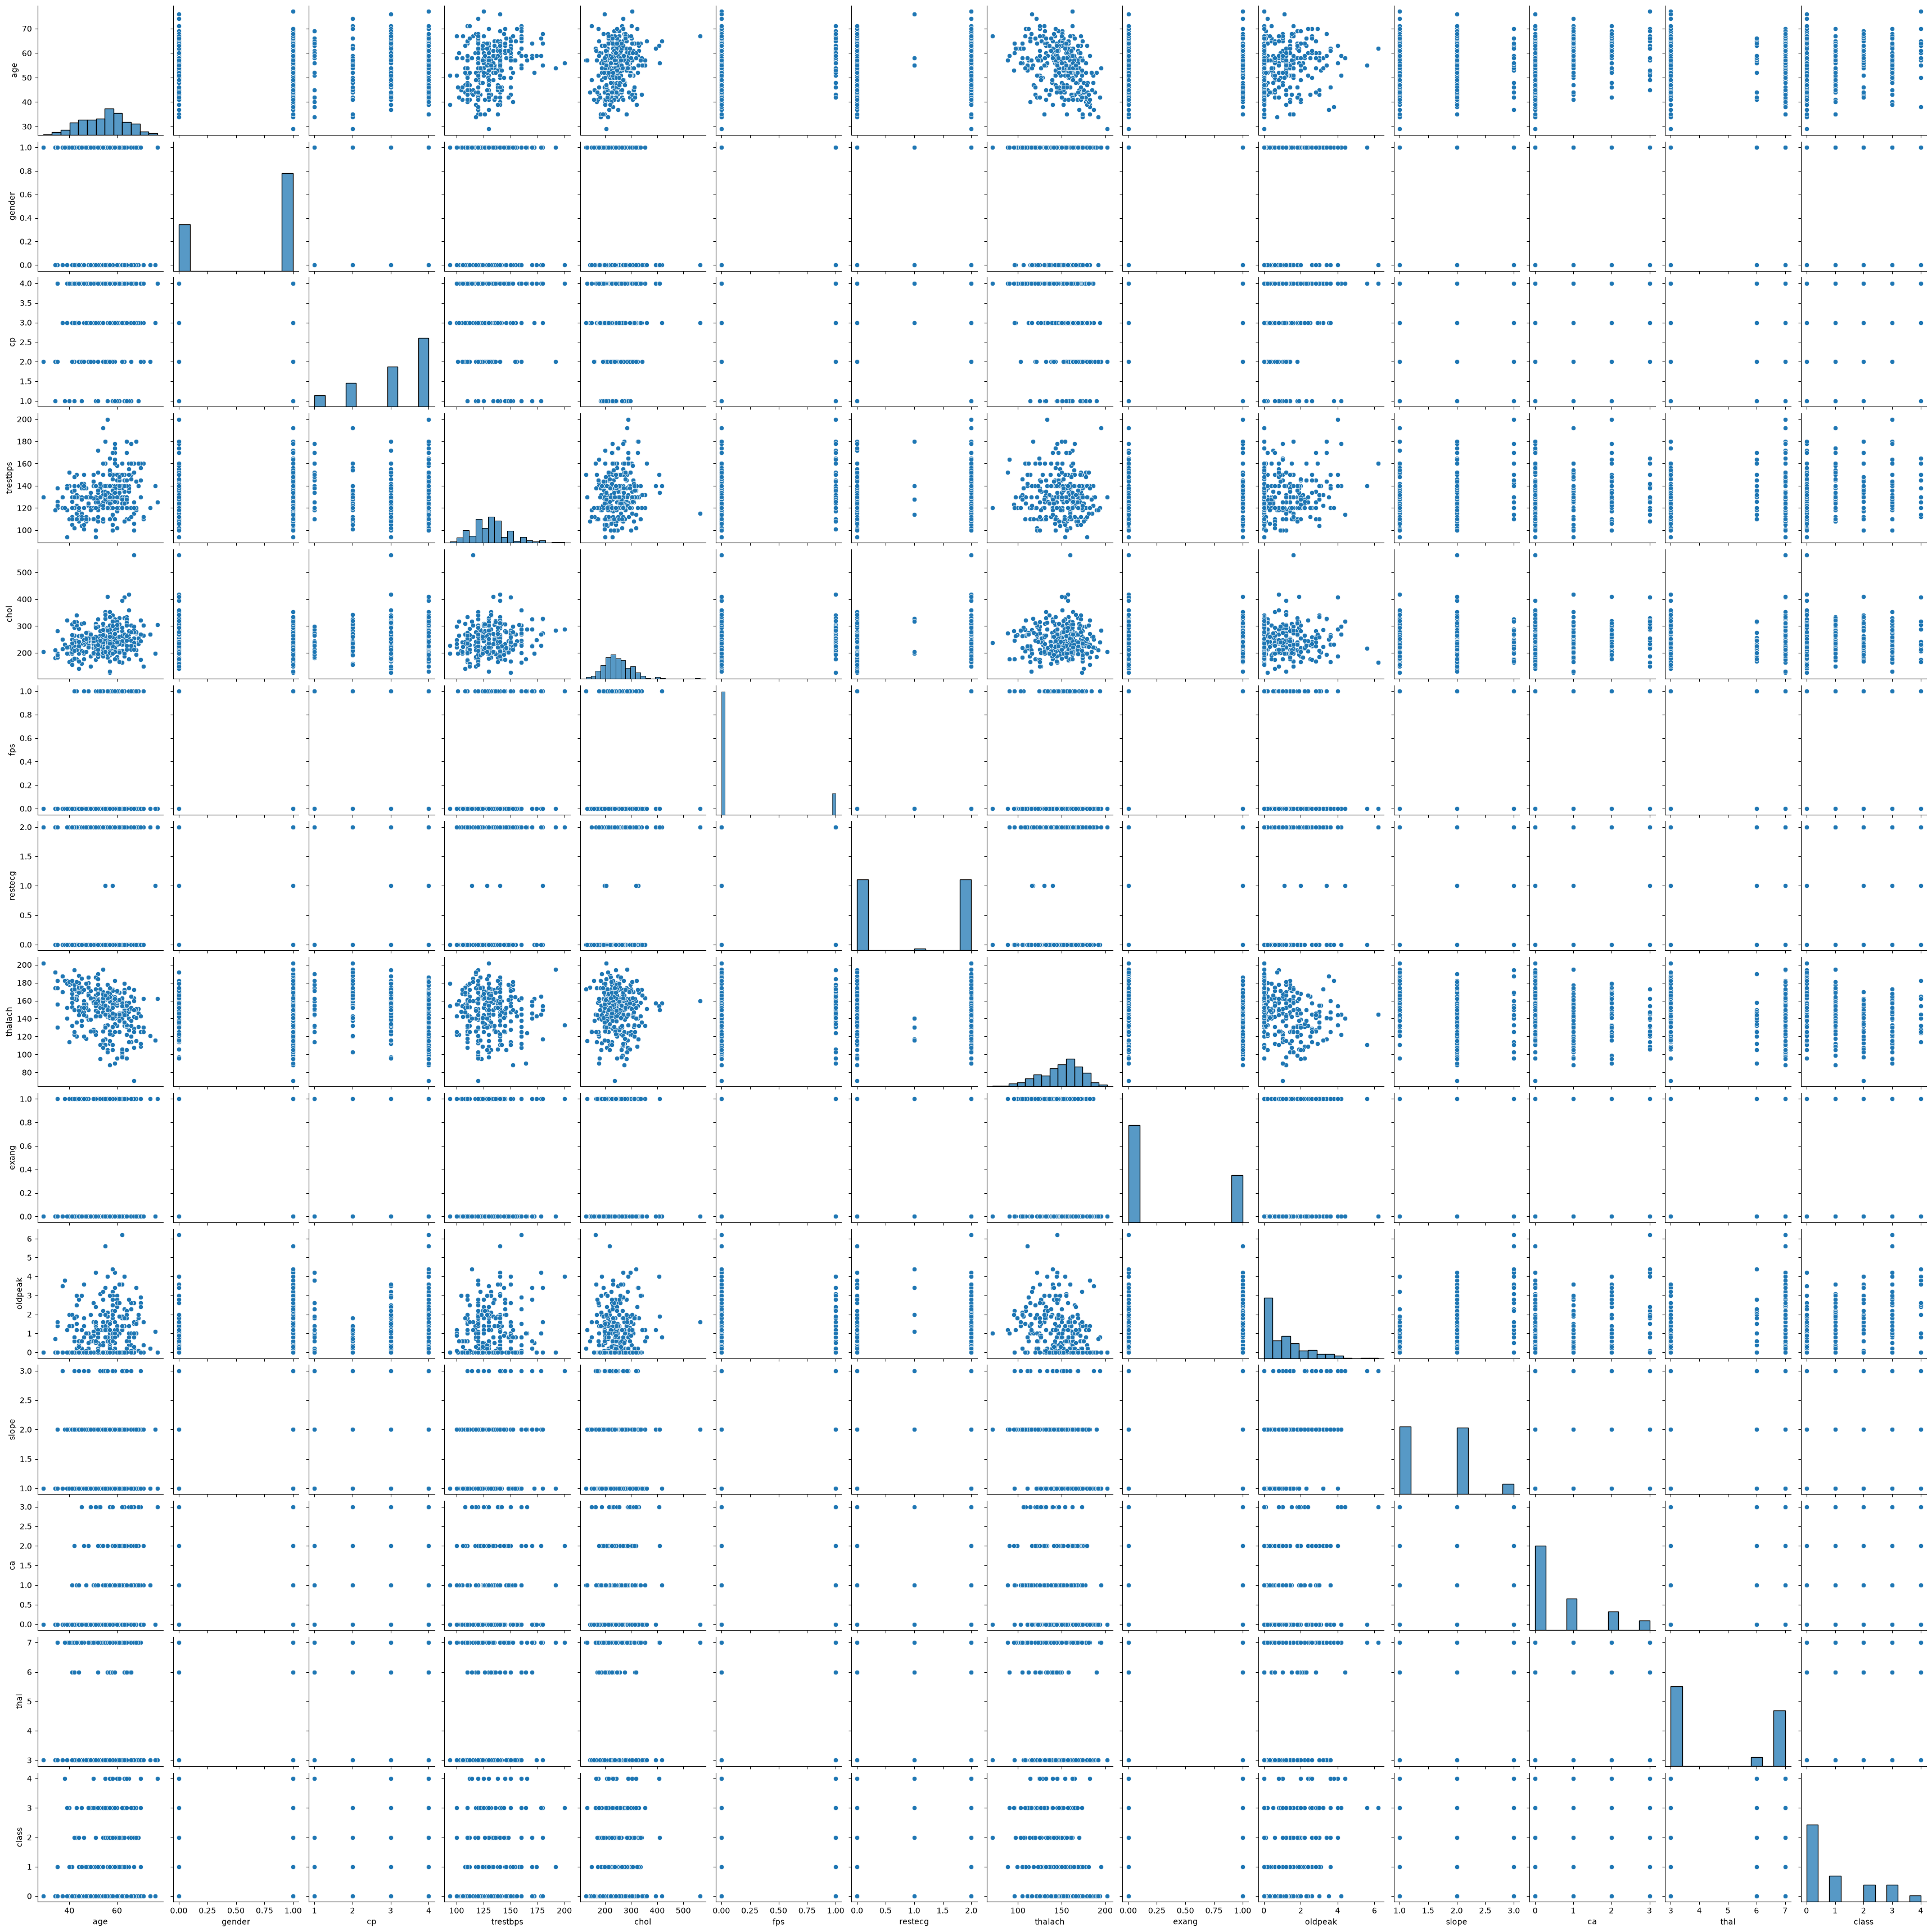

In [40]:
sns.pairplot(heart)

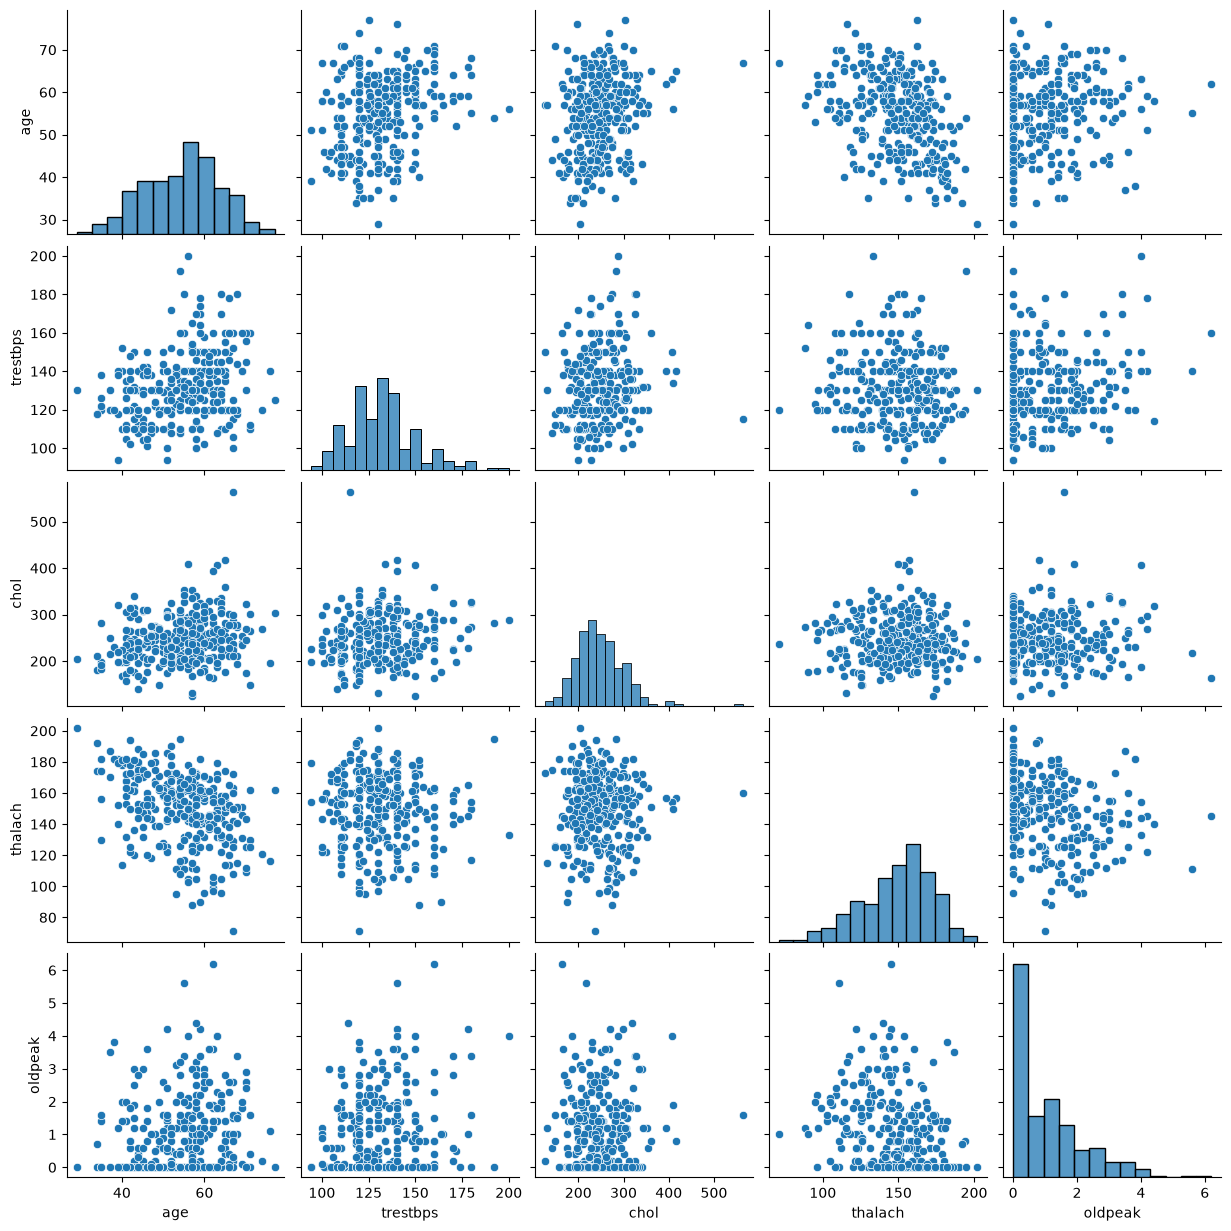

In [41]:
sns.pairplot(heart[['age', 'trestbps', 'chol', 'thalach', 'oldpeak']])

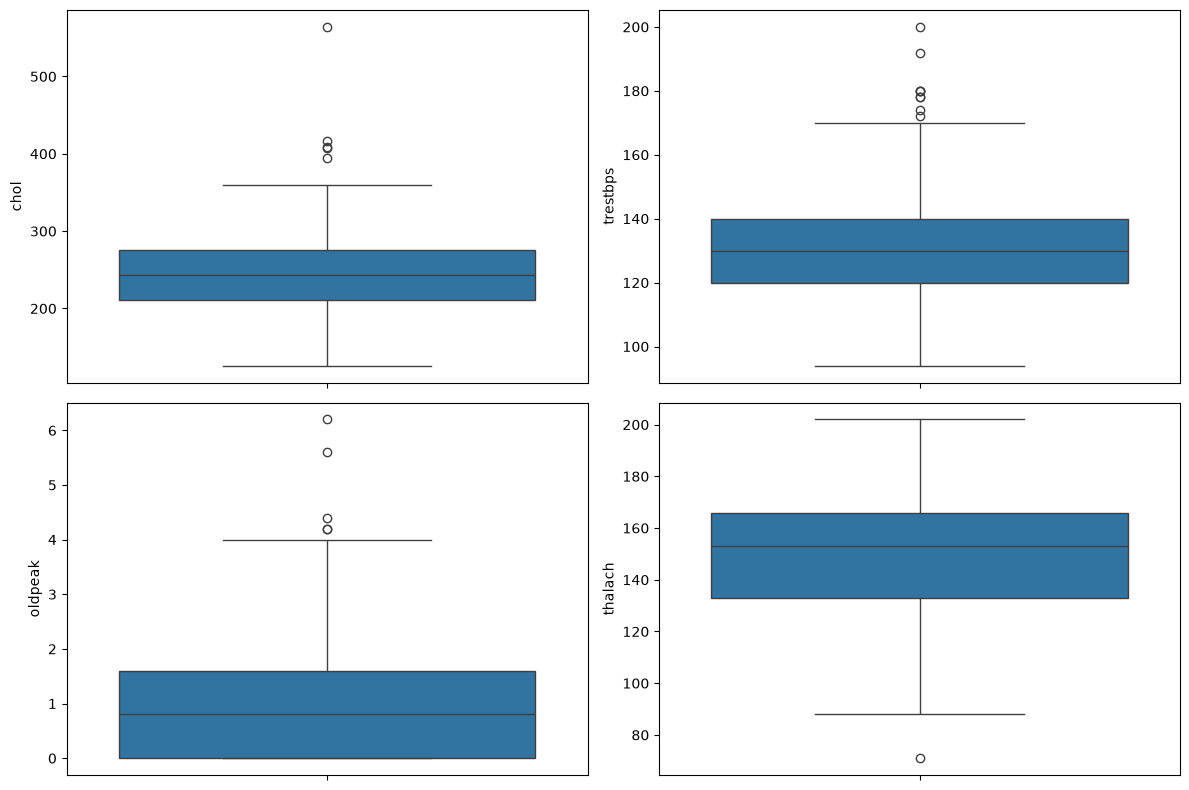

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.boxplot(y=heart['chol'], ax=axes[0, 0])
sns.boxplot(y=heart['trestbps'], ax=axes[0, 1])
sns.boxplot(y=heart['oldpeak'], ax=axes[1, 0])
sns.boxplot(y=heart['thalach'], ax=axes[1, 1])
plt.tight_layout()
plt.show()

In [43]:
def find_outliers_iqr(col):
    Q1 = heart[col].quantile(0.25)
    Q3 = heart[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = heart[(heart[col] < lower) | (heart[col] > upper)]
    print(f"{col}: {len(outliers)} outliers (bounds: {lower: .1f}, {upper: .1f})")
    return outliers

for col in ['chol', 'trestbps', 'oldpeak', 'thalach']:
    find_outliers_iqr(col)

chol: 5 outliers (bounds:  113.5,  373.5)
trestbps: 9 outliers (bounds:  90.0,  170.0)
oldpeak: 5 outliers (bounds: -2.4,  4.0)
thalach: 1 outliers (bounds:  83.5,  215.5)


In [44]:
outlier_rows = find_outliers_iqr('chol')
print(outlier_rows[['age', 'chol', 'class']])

chol: 5 outliers (bounds:  113.5,  373.5)
     age  chol  class
48    65   417      0
121   63   407      4
152   67   564      0
173   62   394      0
181   56   409      2


In [45]:
outlier_rows = find_outliers_iqr('trestbps')
print(outlier_rows[['age', 'trestbps', 'class']])

trestbps: 9 outliers (bounds:  90.0,  170.0)
     age  trestbps  class
14    52       172      0
83    68       180      3
126   56       200      3
172   59       174      1
183   59       178      0
188   54       192      1
201   64       180      0
213   66       178      3
231   55       180      2


In [46]:
outlier_rows = find_outliers_iqr('oldpeak')
print(outlier_rows[['age', 'oldpeak', 'class']])

oldpeak: 5 outliers (bounds: -2.4,  4.0)
     age  oldpeak  class
91    62      6.2      3
123   55      5.6      3
183   59      4.2      0
191   51      4.2      3
285   58      4.4      4


In [47]:
outlier_rows = find_outliers_iqr('thalach')
print(outlier_rows[['age', 'thalach', 'class']])

thalach: 1 outliers (bounds:  83.5,  215.5)
     age  thalach  class
245   67       71      2


In [48]:
print(heart.groupby('gender')['class'].value_counts(normalize=True).unstack())

class          0         1         2         3         4
gender                                                  
0       0.739583  0.093750  0.072917  0.072917  0.020833
1       0.442786  0.223881  0.139303  0.139303  0.054726


In [49]:
print(heart.groupby('cp')['class'].value_counts(normalize=True).unstack())

class         0         1         2         3         4
cp                                                     
1      0.695652  0.217391  0.043478       NaN  0.043478
2      0.816327  0.122449  0.020408  0.040816       NaN
3      0.783133  0.108434  0.048193  0.048193  0.012048
4      0.274648  0.239437  0.204225  0.204225  0.077465


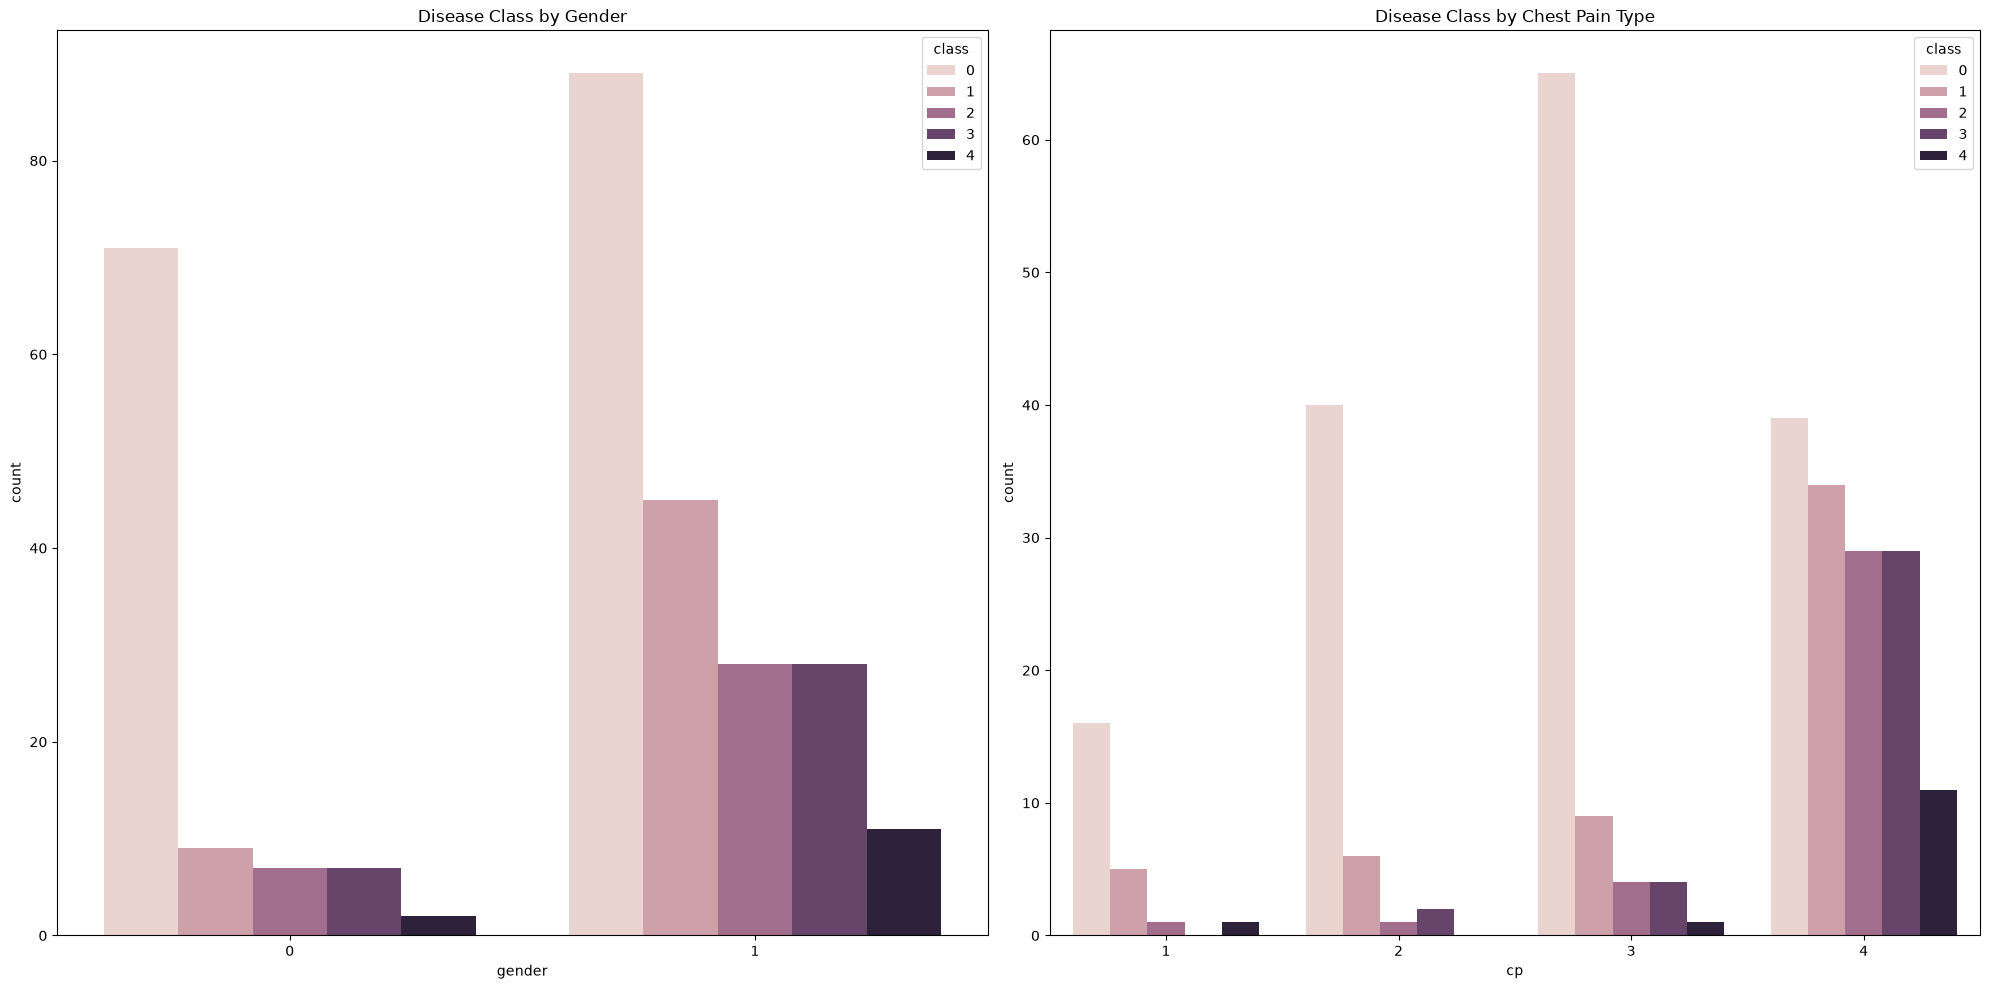

In [ ]:

sns.countplot(data=heart, x='gender', hue='class', ax=axes[0])
axes[0].set_title('Disease Class by Gender')

sns.countplot(data=heart, x='cp', hue='class', ax=axes[1])
axes[1].set_title('Disease Class by Chest Pain Type')
plt.tight_layout()
plt.show()

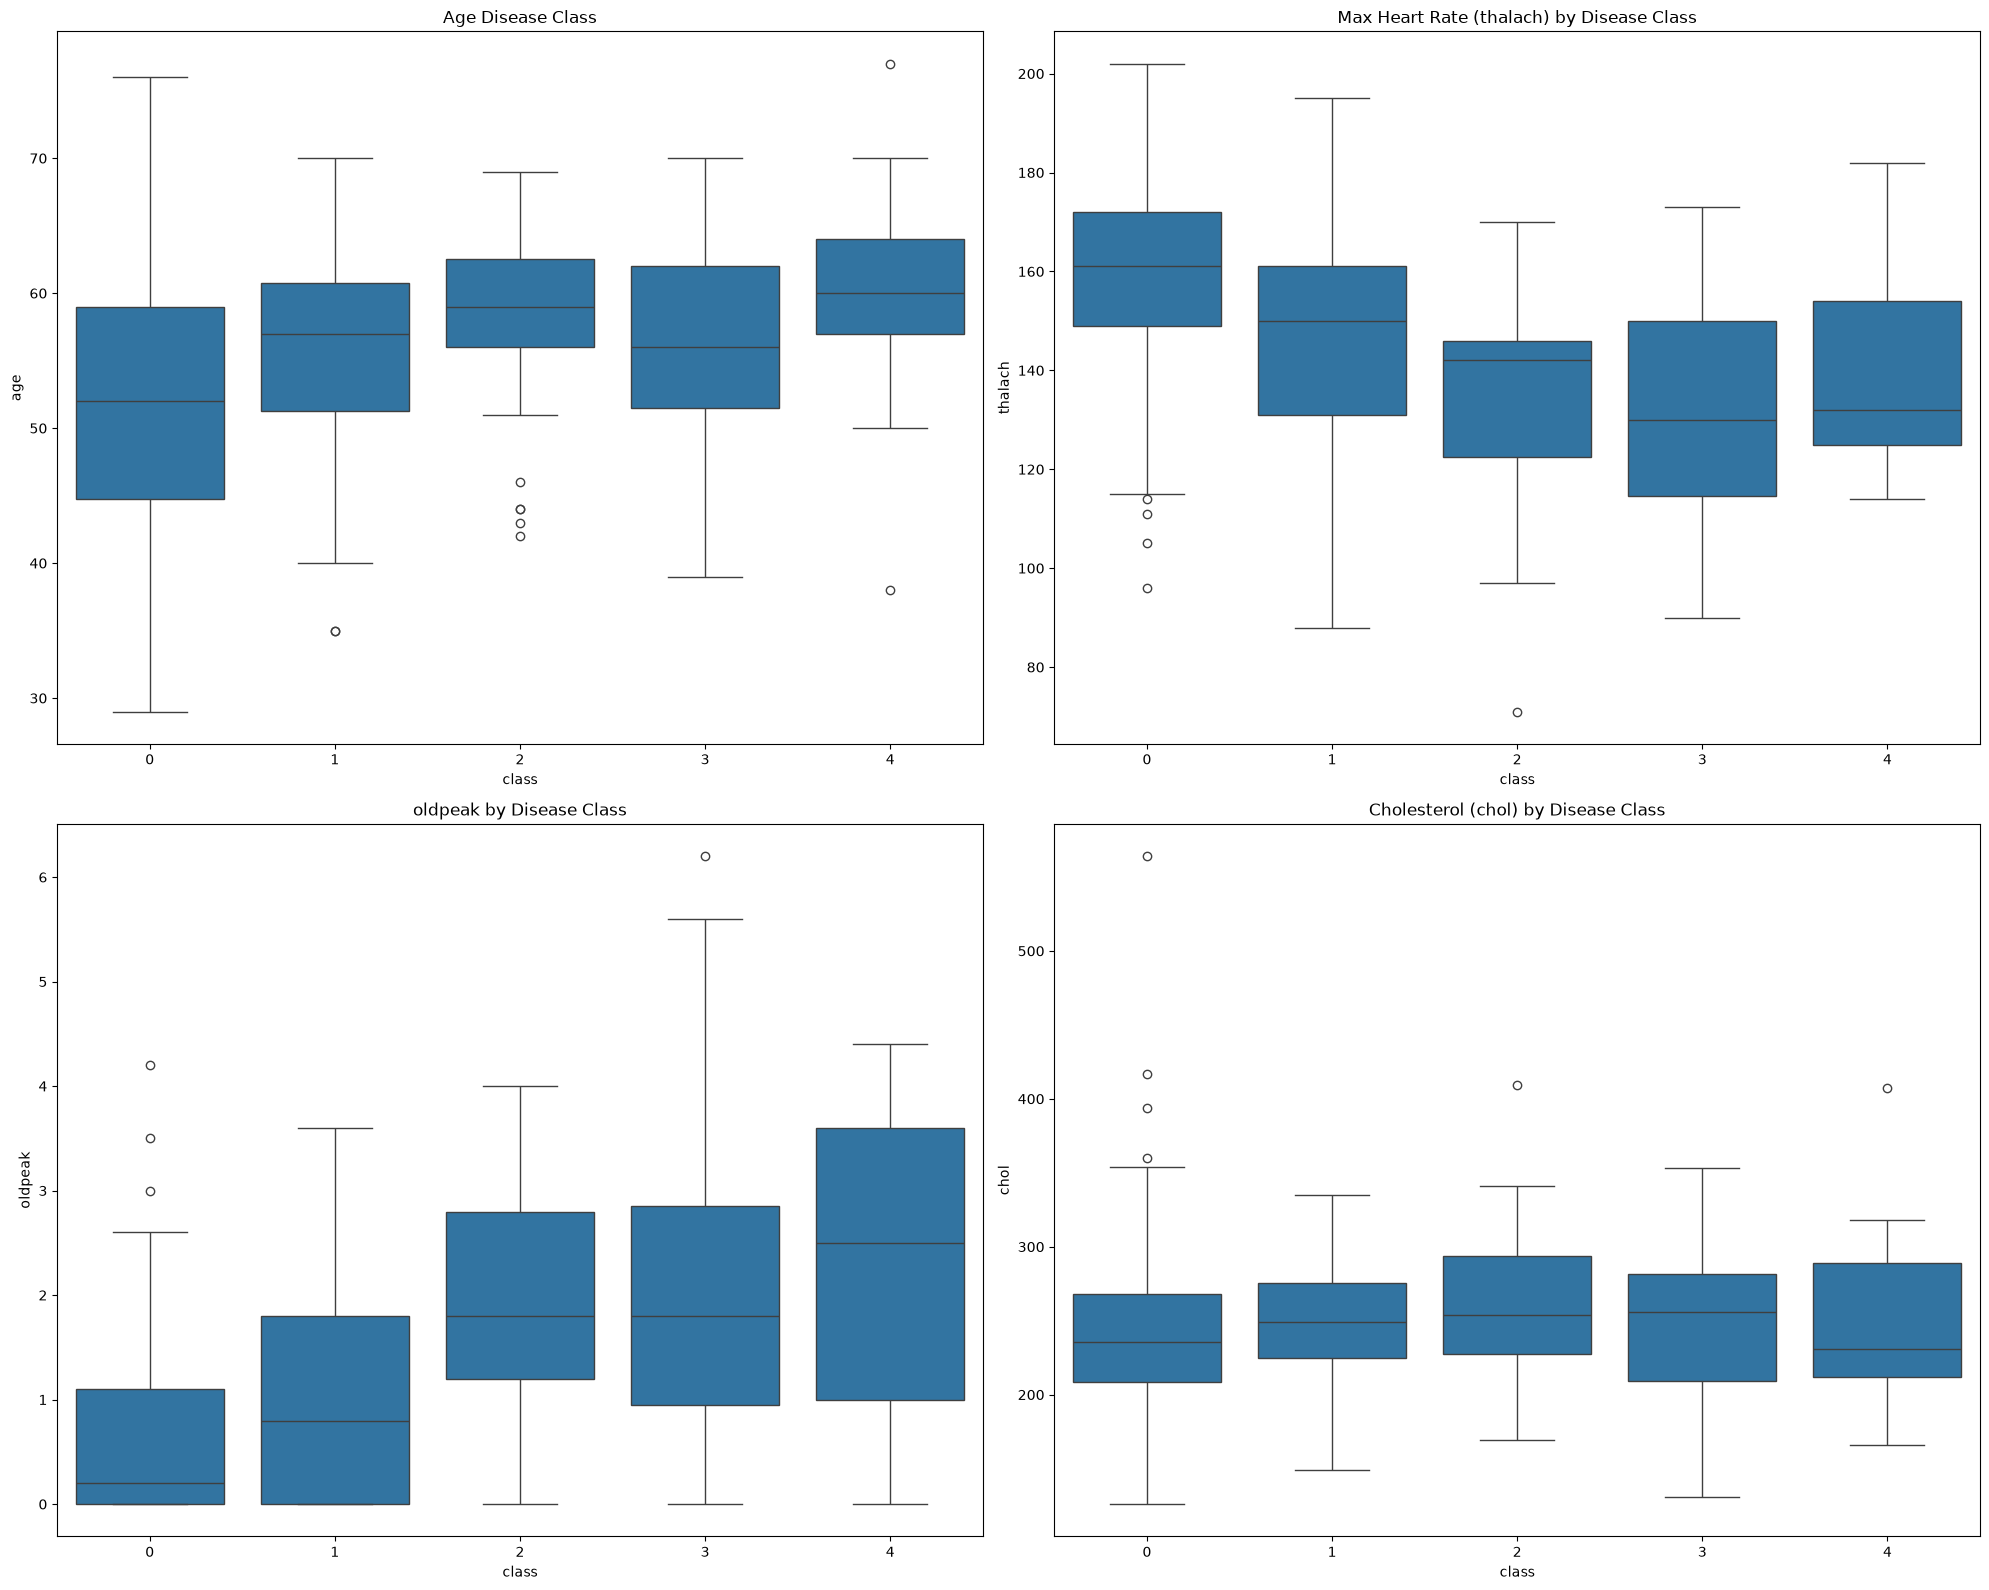

In [53]:
#Continuous variables vs Disease Class
#Concept: Now we flip it around — instead of categorical vs. 
# class, we check whether continuous variables (age, thalach, oldpeak, chol) shift systematically as disease severity increases. 
# Boxplots grouped by class are the standard tool here, since they show the full distribution (median, spread, outliers) per class side-by-side.

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

sns.boxplot(data=heart, x='class', y='age', ax=axes[0, 0])
axes[0, 0].set_title('Age Disease Class')

sns.boxplot(data=heart, x='class', y='thalach', ax=axes[0, 1])
axes[0, 1].set_title('Max Heart Rate (thalach) by Disease Class')

sns.boxplot(data=heart, x='class', y='oldpeak', ax=axes[1, 0])
axes[1, 0].set_title('oldpeak by Disease Class')

sns.boxplot(data=heart, x='class', y='chol', ax=axes[1, 1])
axes[1, 1].set_title('Cholesterol (chol) by Disease Class')

plt.tight_layout()
plt.show()

In [54]:
print(heart.groupby('class')[['age', 'thalach', 'oldpeak', 'chol']].mean())

             age     thalach   oldpeak        chol
class                                             
0      52.643750  158.581250  0.598750  243.493750
1      55.611111  145.981481  1.022222  249.148148
2      58.200000  135.000000  1.802857  260.857143
3      56.000000  132.057143  1.962857  246.457143
4      59.692308  140.615385  2.361538  253.384615


In [55]:
heart['gender_label'] = heart['gender'].map({0: 'Female', 1: 'Male'})
heart['cp_label'] = heart['cp'].map({1: 'Typical Angina', 2: 'Atypical Angina', 3: 'Non-Anginal Pain', 4: 'Asymptomatic'})
heart['class_label'] = heart['class'].map({0: 'No Disease', 1: 'Mild', 2: 'Moderate', 3: 'Severe', 4: 'Very Severe '})

heart.to_csv('clevelanda_cleaned.csv', index=False)

In [56]:
print(heart.dtypes)
print(heart.isnull().sum())

heart.to_csv('clevelanda_cleaned.csv', index=False)

age               int64
gender            int64
cp                int64
trestbps          int64
chol              int64
fps               int64
restecg           int64
thalach           int64
exang             int64
oldpeak         float64
slope             int64
ca                int64
thal              int64
class             int64
gender_label        str
cp_label            str
class_label         str
dtype: object
age             0
gender          0
cp              0
trestbps        0
chol            0
fps             0
restecg         0
thalach         0
exang           0
oldpeak         0
slope           0
ca              0
thal            0
class           0
gender_label    0
cp_label        0
class_label     0
dtype: int64
